In [1]:
import os
import json
import pandas as pd
import numpy as np
from Bio import SeqIO
from collections import Counter

# ── Load CARD FASTA ──────────────────────────────────────────
fasta_path = "data/card/protein_fasta_protein_homolog_model.fasta"
records = list(SeqIO.parse(fasta_path, "fasta"))

print(f"Total sequences loaded: {len(records)}")
print(f"\nSample header: {records[0].description}")
print(f"Sequence length: {len(records[0].seq)}")

Total sequences loaded: 6052

Sample header: gb|ACT97415.1|ARO:3002999|CblA-1 [mixed culture bacterium AX_gF3SD01_15]
Sequence length: 296


In [2]:
# ── Parse gene name and organism from each header ────────────
parsed = []

for rec in records:
    parts = rec.description.split("|")
    
    if len(parts) >= 4:
        aro_id = parts[2].strip()           # e.g. ARO:3002999
        gene_part = parts[3].strip()        # e.g. CblA-1 [organism]
        gene_name = gene_part.split("[")[0].strip()  # e.g. CblA-1
        organism = gene_part.split("[")[1].replace("]","").strip() if "[" in gene_part else "unknown"
        
        parsed.append({
            "id": rec.id,
            "aro_id": aro_id,
            "gene_name": gene_name,
            "organism": organism,
            "sequence": str(rec.seq),
            "seq_length": len(rec.seq)
        })

df = pd.DataFrame(parsed)
print(f"Successfully parsed: {len(df)} sequences")
print(f"\nDataframe shape: {df.shape}")
print(f"\nSample rows:")
df.head()

Successfully parsed: 6052 sequences

Dataframe shape: (6052, 6)

Sample rows:


,id,aro_id,gene_name,organism,sequence,seq_length
0,gb|ACT97415.1|ARO:3002999|CblA-1,ARO:3002999,CblA-1,mixed culture bacterium AX_gF3SD01_15,MKAYFIAILTLFTCIATVVRAQQMSELENRIDSLLNGKKATVGIAV...,296
1,gb|AEJ08681.1|ARO:3001109|SHV-52,ARO:3001109,SHV-52,Klebsiella pneumoniae,MRYIRLCIISLLAALPLAVHASPQPLEQIKQSESQLSGRVGMIEMD...,286
2,gb|AAD01868.1|ARO:3002867|dfrF,ARO:3002867,dfrF,Enterococcus faecalis,MIGLIVARSKNNVIGKNGNIPWKIKGEQKQFRELTTGNVVIMGRKS...,164
3,gb|AFJ59957.1|ARO:3001989|CTX-M-130,ARO:3001989,CTX-M-130,Escherichia coli,MVTKRVQRMMFAAAACIPLLLGSAPLYAQTSAVQQKLAALEKSSGG...,291
4,gb|AEX08599.1|ARO:3002356|NDM-6,ARO:3002356,NDM-6,Escherichia coli,MELPNIMHPVAKLSTALAAALMLSGCMPGEIRPTIGQQMETGDQRF...,270


In [3]:
# ── How many unique genes do we have? ────────────────────────
print(f"Unique gene names: {df['gene_name'].nunique()}")
print(f"Unique ARO IDs: {df['aro_id'].nunique()}")
print(f"\nSequence length stats:")
print(df['seq_length'].describe())

print(f"\nTop 20 most common gene families:")
print(df['gene_name'].value_counts().head(20))

Unique gene names: 6052
Unique ARO IDs: 6052

Sequence length stats:
count    6052.000000
mean      320.285030
std       101.306291
min        53.000000
25%       273.000000
50%       290.000000
75%       381.000000
max      1452.000000
Name: seq_length, dtype: float64

Top 20 most common gene families:
gene_name
AAC_3Ib_AAC_6Ib    1
CblA-1             1
SHV-52             1
dfrF               1
TEM-248            1
TEM-249            1
TEM-250            1
TEM-251            1
TEM-252            1
TEM-253            1
TEM-254            1
TEM-255            1
SHV-240            1
SHV-241            1
SHV-242            1
SHV-243            1
SHV-244            1
SHV-245            1
SRT-4              1
TEM-239            1
Name: count, dtype: int64


In [4]:
# ── Load card.json to extract resistance class labels ─────────
with open("data/card/card.json") as f:
    card = json.load(f)

# Each key is a numeric ID, each value is a dict
# Let's look at one entry in detail
sample_key = list(card.keys())[10]
sample_entry = card[sample_key]

print(f"Sample entry keys: {list(sample_entry.keys())}")

Sample entry keys: ['model_id', 'model_name', 'model_type', 'model_type_id', 'model_description', 'model_param', 'model_sequences', 'ARO_accession', 'ARO_id', 'ARO_name', 'CARD_short_name', 'ARO_description', 'ARO_category']


In [5]:
# Look at ARO_category in detail for a few entries
count = 0
for key, entry in card.items():
    if 'ARO_category' in entry and entry['ARO_category']:
        print(f"\nEntry: {entry.get('ARO_name', 'N/A')}")
        print(f"ARO_category content:")
        for cat_id, cat_val in entry['ARO_category'].items():
            print(f"  {cat_val}")
        count += 1
    if count == 3:
        break


Entry: CblA-1
ARO_category content:
  {'category_aro_accession': '3002998', 'category_aro_cvterm_id': '39432', 'category_aro_name': 'CblA beta-lactamase', 'category_aro_description': 'CblA beta-lactamases are class A beta-lactamases that confer resistance to cephalosporins.', 'category_aro_class_name': 'AMR Gene Family'}
  {'category_aro_accession': '3004129', 'category_aro_cvterm_id': '41256', 'category_aro_name': 'cephaloridine', 'category_aro_description': 'Cephaloridine is a semisynthetic, broad-spectrum, first-generation cephalosporin with antibacterial activity. Cephaloridine binds to and inactivates penicillin-binding proteins (PBPs) located on the inner membrane of the bacterial cell wall. PBPs are enzymes involved in the terminal stages of assembling the bacterial cell wall and in reshaping the cell wall during growth and division. Inactivation of PBPs interferes with the cross-linkage of peptidoglycan chains necessary for bacterial cell wall strength and rigidity. This resul

In [6]:
# See all unique category types present
category_types = set()

for key, entry in card.items():
    if 'ARO_category' in entry:
        for cat_id, cat_val in entry['ARO_category'].items():
            if isinstance(cat_val, dict):
                category_types.add(cat_val.get('category_aro_class_name', 'unknown'))

print("All category class names present in CARD:")
for c in sorted(category_types):
    print(f"  {c}")

All category class names present in CARD:
  AMR Gene Family
  Adjuvant
  Antibiotic
  Antibiotic+Adjuvant
  Drug Class
  Efflux Component
  Efflux Regulator
  Resistance Mechanism


In [11]:
aro_to_drugclass = {}

for key, entry in card.items():
    if not isinstance(entry, dict):
        continue
    
    aro_acc = entry.get('ARO_accession', None)
    if not aro_acc:
        continue
    
    drug_classes = []
    aro_category = entry.get('ARO_category', {})
    
    if isinstance(aro_category, dict):
        for cat_id, cat_val in aro_category.items():
            if isinstance(cat_val, dict):
                if cat_val.get('category_aro_class_name') == 'Drug Class':
                    drug_classes.append(cat_val.get('category_aro_name', ''))
    
    if drug_classes:
        aro_to_drugclass[aro_acc] = drug_classes

print(f"Total ARO entries with Drug Class labels: {len(aro_to_drugclass)}")
print(f"\nSample mappings:")
for k, v in list(aro_to_drugclass.items())[:5]:
    print(f"  ARO:{k} → {v}")

Total ARO entries with Drug Class labels: 6435

Sample mappings:
  ARO:3002999 → ['cephalosporin']
  ARO:3001109 → ['cephalosporin', 'penicillin beta-lactam']
  ARO:3002867 → ['diaminopyrimidine antibiotic']
  ARO:3001989 → ['cephalosporin']
  ARO:3002356 → ['carbapenem', 'cephalosporin', 'penicillin beta-lactam']


In [12]:
# Map drug class back to our sequence dataframe
# ARO id in df looks like 'ARO:3002999', in json it's just '3002999'

def get_drug_class(aro_id):
    # Strip 'ARO:' prefix
    acc = aro_id.replace('ARO:', '').strip()
    classes = aro_to_drugclass.get(acc, [])
    if classes:
        return classes[0]  # Take primary drug class
    return None

df['drug_class'] = df['aro_id'].apply(get_drug_class)

# Check how many got labeled
labeled = df[df['drug_class'].notna()]
unlabeled = df[df['drug_class'].isna()]

print(f"Successfully labeled: {len(labeled)}")
print(f"Unlabeled: {len(unlabeled)}")
print(f"\nDrug class distribution:")
print(labeled['drug_class'].value_counts())

Successfully labeled: 6048
Unlabeled: 4

Drug class distribution:
drug_class
carbapenem                             1634
cephalosporin                          1401
monobactam                             1286
penicillin beta-lactam                  590
aminoglycoside antibiotic               200
fluoroquinolone antibiotic              183
macrolide antibiotic                    165
peptide antibiotic                      139
glycopeptide antibiotic                  81
tetracycline antibiotic                  79
diaminopyrimidine antibiotic             58
phenicol antibiotic                      52
lincosamide antibiotic                   44
phosphonic acid antibiotic               36
rifamycin antibiotic                     18
streptogramin antibiotic                 13
nitroimidazole antibiotic                13
disinfecting agents and antiseptics      12
nucleoside antibiotic                    10
glycylcycline                            10
fusidane antibiotic                       5

In [13]:
# Keep only classes with enough sequences for training
# Minimum 30 sequences per class

class_counts = labeled['drug_class'].value_counts()
valid_classes = class_counts[class_counts >= 30].index.tolist()

print(f"Classes with 30+ sequences: {len(valid_classes)}")
print(f"\nValid classes:")
for c in valid_classes:
    print(f"  {c}: {class_counts[c]} sequences")

# Filter dataframe
df_clean = labeled[labeled['drug_class'].isin(valid_classes)].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nFinal dataset size: {len(df_clean)} sequences")
print(f"Number of classes: {df_clean['drug_class'].nunique()}")

Classes with 30+ sequences: 14

Valid classes:
  carbapenem: 1634 sequences
  cephalosporin: 1401 sequences
  monobactam: 1286 sequences
  penicillin beta-lactam: 590 sequences
  aminoglycoside antibiotic: 200 sequences
  fluoroquinolone antibiotic: 183 sequences
  macrolide antibiotic: 165 sequences
  peptide antibiotic: 139 sequences
  glycopeptide antibiotic: 81 sequences
  tetracycline antibiotic: 79 sequences
  diaminopyrimidine antibiotic: 58 sequences
  phenicol antibiotic: 52 sequences
  lincosamide antibiotic: 44 sequences
  phosphonic acid antibiotic: 36 sequences

Final dataset size: 5948 sequences
Number of classes: 14


In [14]:
# Save for later use so we don't have to reparse every time
df_clean.to_csv("data/amr_labeled.csv", index=False)
print("Saved to data/amr_labeled.csv")
print(f"\nFinal class distribution:")
print(df_clean['drug_class'].value_counts())

Saved to data/amr_labeled.csv

Final class distribution:
drug_class
carbapenem                      1634
cephalosporin                   1401
monobactam                      1286
penicillin beta-lactam           590
aminoglycoside antibiotic        200
fluoroquinolone antibiotic       183
macrolide antibiotic             165
peptide antibiotic               139
glycopeptide antibiotic           81
tetracycline antibiotic           79
diaminopyrimidine antibiotic      58
phenicol antibiotic               52
lincosamide antibiotic            44
phosphonic acid antibiotic        36
Name: count, dtype: int64


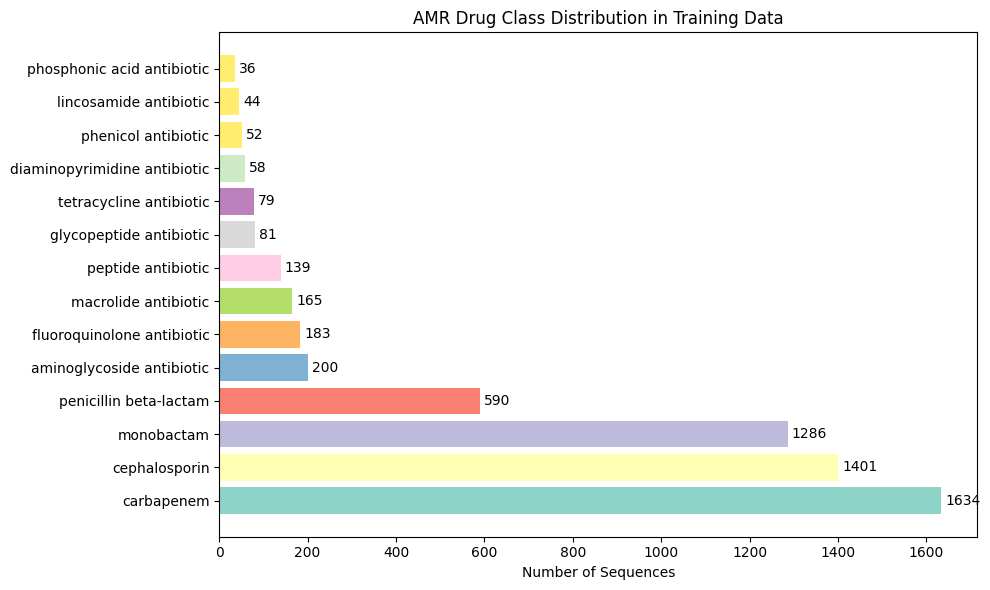

Plot saved


In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

counts = df_clean['drug_class'].value_counts()
colors = plt.cm.Set3(range(len(counts)))

bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("Number of Sequences")
ax.set_title("AMR Drug Class Distribution in Training Data")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig("data/class_distribution.png", dpi=150)
plt.show()
print("Plot saved")

In [16]:
from itertools import product

def get_kmers(sequence, k=3):
    """Generate all possible amino acid k-mers"""
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    all_kmers = [''.join(p) for p in product(amino_acids, repeat=k)]
    kmer_index = {km: i for i, km in enumerate(all_kmers)}
    
    # Count k-mers in sequence
    vector = np.zeros(len(all_kmers))
    seq = sequence.upper()
    
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in kmer_index:
            vector[kmer_index[kmer]] += 1
    
    # Normalize by total kmers
    total = vector.sum()
    if total > 0:
        vector = vector / total
    
    return vector

# Test on one sequence
test_vec = get_kmers(df_clean['sequence'].iloc[0], k=3)
print(f"K-mer vector length: {len(test_vec)}")
print(f"Non-zero features: {np.count_nonzero(test_vec)}")
print(f"Vector sum (should be ~1.0): {test_vec.sum():.4f}")

K-mer vector length: 8000
Non-zero features: 287
Vector sum (should be ~1.0): 1.0000


In [17]:
print("Computing k-mer features for all sequences...")
print("This may take 1-2 minutes...")

X = np.array([get_kmers(seq, k=3) for seq in df_clean['sequence']])
y = df_clean['drug_class'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nSample of labels: {y[:5]}")

# Save features
np.save("data/X_features.npy", X)
np.save("data/y_labels.npy", y)
print("\nFeatures saved to data/")

Computing k-mer features for all sequences...
This may take 1-2 minutes...

Feature matrix shape: (5948, 8000)
Labels shape: (5948,)

Sample of labels: ['cephalosporin' 'cephalosporin' 'diaminopyrimidine antibiotic'
 'cephalosporin' 'carbapenem']

Features saved to data/


In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode string labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Classes: {list(le.classes_)}")
print(f"Encoded as: {list(range(len(le.classes_)))}")
print(f"\nTotal classes: {len(le.classes_)}")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # ensures balanced split across classes
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Classes: ['aminoglycoside antibiotic', 'carbapenem', 'cephalosporin', 'diaminopyrimidine antibiotic', 'fluoroquinolone antibiotic', 'glycopeptide antibiotic', 'lincosamide antibiotic', 'macrolide antibiotic', 'monobactam', 'penicillin beta-lactam', 'peptide antibiotic', 'phenicol antibiotic', 'phosphonic acid antibiotic', 'tetracycline antibiotic']
Encoded as: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

Total classes: 14

Training set: (4758, 8000)
Test set: (1190, 8000)


In [19]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

print("Training ANN...")
print("This may take 3-5 minutes...\n")

ann = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # 3 hidden layers
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    verbose=True,                        # shows progress each iteration
    early_stopping=True,                 # stops if validation stops improving
    validation_fraction=0.1,
    n_iter_no_change=5
)

start = time.time()
ann.fit(X_train, y_train)
end = time.time()

print(f"\nTraining completed in {(end-start):.1f} seconds")
print(f"Iterations run: {ann.n_iter_}")

Training ANN...
This may take 3-5 minutes...

Iteration 1, loss = 2.45619471
Validation score: 0.235294
Iteration 2, loss = 2.02406528
Validation score: 0.674370
Iteration 3, loss = 1.55041445
Validation score: 0.680672
Iteration 4, loss = 1.11407560
Validation score: 0.712185
Iteration 5, loss = 0.87496893
Validation score: 0.768908
Iteration 6, loss = 0.73656449
Validation score: 0.808824
Iteration 7, loss = 0.62441533
Validation score: 0.836134
Iteration 8, loss = 0.53310473
Validation score: 0.848739
Iteration 9, loss = 0.46389166
Validation score: 0.855042
Iteration 10, loss = 0.40671062
Validation score: 0.871849
Iteration 11, loss = 0.35906765
Validation score: 0.865546
Iteration 12, loss = 0.31537265
Validation score: 0.871849
Iteration 13, loss = 0.27867952
Validation score: 0.876050
Iteration 14, loss = 0.24598373
Validation score: 0.873950
Iteration 15, loss = 0.21549964
Validation score: 0.880252
Iteration 16, loss = 0.18825227
Validation score: 0.886555
Iteration 17, loss 

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Predictions
y_pred = ann.predict(X_test)

# Overall accuracy
accuracy = (y_pred == y_test).mean()
print(f"Overall Accuracy: {accuracy*100:.2f}%\n")

# Detailed per-class report
print("Per-class Performance:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

Overall Accuracy: 92.52%

Per-class Performance:
                              precision    recall  f1-score   support

   aminoglycoside antibiotic       0.96      0.60      0.74        40
                  carbapenem       0.98      0.97      0.98       327
               cephalosporin       0.99      0.98      0.98       280
diaminopyrimidine antibiotic       1.00      0.67      0.80        12
  fluoroquinolone antibiotic       0.86      0.68      0.76        37
     glycopeptide antibiotic       1.00      0.44      0.61        16
      lincosamide antibiotic       0.57      0.44      0.50         9
        macrolide antibiotic       0.37      0.76      0.50        33
                  monobactam       1.00      0.99      0.99       257
      penicillin beta-lactam       0.93      0.95      0.94       118
          peptide antibiotic       0.96      0.82      0.88        28
         phenicol antibiotic       0.60      0.90      0.72        10
  phosphonic acid antibiotic       1.00 

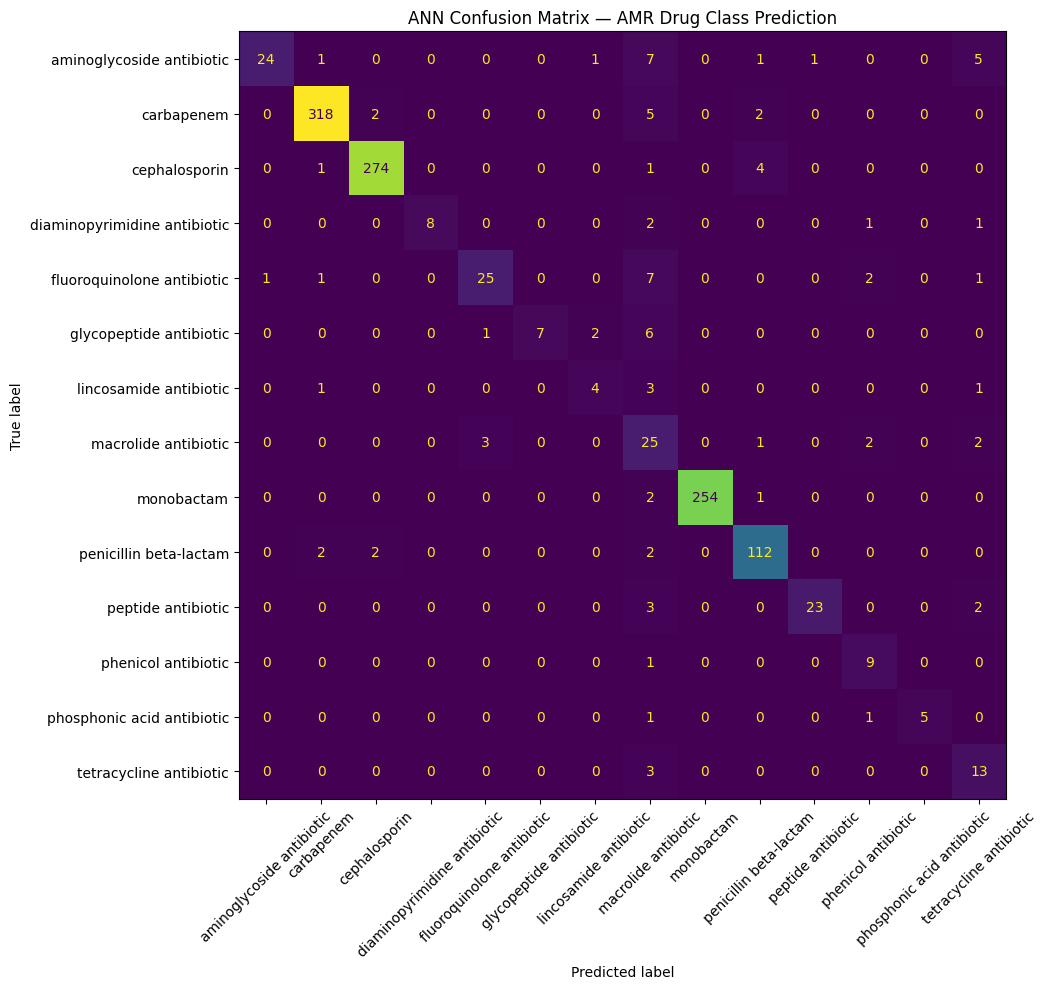

Saved confusion matrix


In [21]:
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax,
    colorbar=False
)

ax.set_title("ANN Confusion Matrix — AMR Drug Class Prediction")
plt.tight_layout()
plt.savefig("data/confusion_matrix.png", dpi=150)
plt.show()
print("Saved confusion matrix")

In [22]:
import pickle

# Save model
with open("models/ann_model.pkl", "wb") as f:
    pickle.dump(ann, f)

# Save label encoder
with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model saved to models/ann_model.pkl")
print("Label encoder saved to models/label_encoder.pkl")

Model saved to models/ann_model.pkl
Label encoder saved to models/label_encoder.pkl


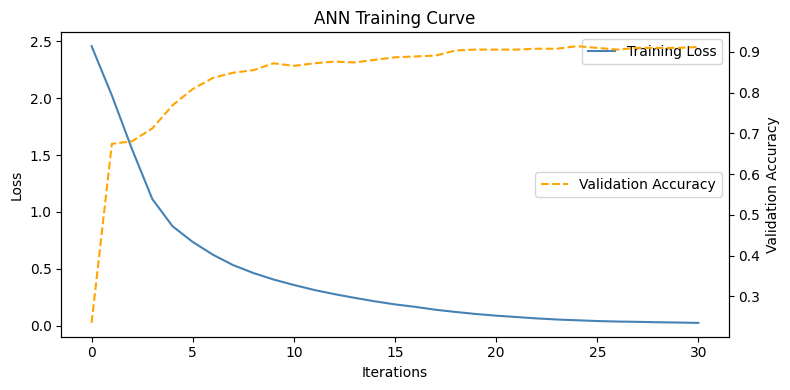

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ann.loss_curve_, label='Training Loss', color='steelblue')
if ann.validation_scores_ is not None:
    # Plot validation score on secondary axis
    ax2 = ax.twinx()
    ax2.plot(ann.validation_scores_, label='Validation Accuracy', 
             color='orange', linestyle='--')
    ax2.set_ylabel('Validation Accuracy')
    ax2.legend(loc='center right')

ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')
ax.set_title('ANN Training Curve')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("data/training_curve.png", dpi=150)
plt.show()

In [24]:
# TEM-1 beta-lactamase - one of the most well known AMR proteins
# Confers penicillin/ampicillin resistance
tem1 = """MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPVAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW"""

# Compute features
tem1_features = get_kmers(tem1, k=3).reshape(1, -1)

# Predict
predicted_class = le.inverse_transform(ann.predict(tem1_features))[0]
probabilities = ann.predict_proba(tem1_features)[0]
confidence = probabilities.max() * 100

print(f"Query: TEM-1 beta-lactamase")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print(f"\nTop 3 predictions:")
top3_idx = probabilities.argsort()[-3:][::-1]
for idx in top3_idx:
    print(f"  {le.classes_[idx]}: {probabilities[idx]*100:.2f}%")

Query: TEM-1 beta-lactamase
Predicted class: monobactam
Confidence: 100.00%

Top 3 predictions:
  monobactam: 100.00%
  penicillin beta-lactam: 0.00%
  carbapenem: 0.00%


In [25]:
# Check how TEM family is labeled in our dataset
tem_sequences = df_clean[df_clean['gene_name'].str.contains('TEM', case=False)]

print(f"Total TEM sequences in dataset: {len(tem_sequences)}")
print(f"\nDrug class distribution for TEM family:")
print(tem_sequences['drug_class'].value_counts())

Total TEM sequences in dataset: 216

Drug class distribution for TEM family:
drug_class
monobactam    216
Name: count, dtype: int64


In [26]:
# Check beta-lactam related classes and their gene families
betalactam_classes = [
    'penicillin beta-lactam',
    'cephalosporin', 
    'carbapenem',
    'monobactam'
]

print("Gene families per beta-lactam class:\n")
for cls in betalactam_classes:
    subset = df_clean[df_clean['drug_class'] == cls]
    top_genes = subset['gene_name'].apply(
        lambda x: x.split('-')[0]  # Get family prefix e.g. TEM, SHV, CTX
    ).value_counts().head(5)
    print(f"{cls} ({len(subset)} sequences):")
    print(top_genes.to_string())
    print()

Gene families per beta-lactam class:

penicillin beta-lactam (590 sequences):
gene_name
OXA     374
CARB     54
LEN      44
PEN      39
FONA     13

cephalosporin (1401 sequences):
gene_name
ADC    325
CTX    265
SHV    216
CMY    189
OXA    116

carbapenem (1634 sequences):
gene_name
OXA    781
ACT    171
IMP     99
VIM     89
NDM     70

monobactam (1286 sequences):
gene_name
PDC    639
KPC    230
TEM    216
OXY     73
VEB     39



In [27]:
# Merge all beta-lactam subclasses
betalactam_map = {
    'monobactam': 'beta-lactam antibiotic',
    'carbapenem': 'beta-lactam antibiotic',
    'cephalosporin': 'beta-lactam antibiotic',
    'penicillin beta-lactam': 'beta-lactam antibiotic'
}

df_clean['drug_class_merged'] = df_clean['drug_class'].replace(betalactam_map)

print("New class distribution:")
print(df_clean['drug_class_merged'].value_counts())
print(f"\nTotal classes: {df_clean['drug_class_merged'].nunique()}")

New class distribution:
drug_class_merged
beta-lactam antibiotic          4911
aminoglycoside antibiotic        200
fluoroquinolone antibiotic       183
macrolide antibiotic             165
peptide antibiotic               139
glycopeptide antibiotic           81
tetracycline antibiotic           79
diaminopyrimidine antibiotic      58
phenicol antibiotic               52
lincosamide antibiotic            44
phosphonic acid antibiotic        36
Name: count, dtype: int64

Total classes: 11


In [28]:
# Rebuild features and labels with merged classes
y_merged = df_clean['drug_class_merged'].values

# Re-encode
le2 = LabelEncoder()
y_encoded2 = le2.fit_transform(y_merged)

print(f"Classes: {list(le2.classes_)}")

# Resplit
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_encoded2,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded2
)

print(f"\nTraining set: {X_train2.shape}")
print(f"Test set: {X_test2.shape}")

Classes: ['aminoglycoside antibiotic', 'beta-lactam antibiotic', 'diaminopyrimidine antibiotic', 'fluoroquinolone antibiotic', 'glycopeptide antibiotic', 'lincosamide antibiotic', 'macrolide antibiotic', 'peptide antibiotic', 'phenicol antibiotic', 'phosphonic acid antibiotic', 'tetracycline antibiotic']

Training set: (4758, 8000)
Test set: (1190, 8000)


In [29]:
print("Retraining with merged classes...")

ann2 = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5
)

start = time.time()
ann2.fit(X_train2, y_train2)
end = time.time()

print(f"\nTraining completed in {(end-start):.1f} seconds")
print(f"Iterations run: {ann2.n_iter_}")

Retraining with merged classes...
Iteration 1, loss = 2.06062823
Validation score: 0.794118
Iteration 2, loss = 1.02187333
Validation score: 0.794118
Iteration 3, loss = 0.75659159
Validation score: 0.794118
Iteration 4, loss = 0.66289179
Validation score: 0.794118
Iteration 5, loss = 0.57987425
Validation score: 0.794118
Iteration 6, loss = 0.49989845
Validation score: 0.819328
Iteration 7, loss = 0.44358694
Validation score: 0.821429
Iteration 8, loss = 0.40657041
Validation score: 0.823529
Iteration 9, loss = 0.37746028
Validation score: 0.840336
Iteration 10, loss = 0.35389739
Validation score: 0.844538
Iteration 11, loss = 0.32980729
Validation score: 0.840336
Iteration 12, loss = 0.30564562
Validation score: 0.842437
Iteration 13, loss = 0.28344816
Validation score: 0.842437
Iteration 14, loss = 0.26220804
Validation score: 0.844538
Iteration 15, loss = 0.24010393
Validation score: 0.846639
Iteration 16, loss = 0.22098865
Validation score: 0.850840
Iteration 17, loss = 0.20122644

In [30]:
y_pred2 = ann2.predict(X_test2)
accuracy2 = (y_pred2 == y_test2).mean()

print(f"New Overall Accuracy: {accuracy2*100:.2f}%\n")
print(classification_report(y_test2, y_pred2, target_names=le2.classes_))

# Sanity test with TEM-1 again
predicted2 = le2.inverse_transform(ann2.predict(tem1_features))[0]
probs2 = ann2.predict_proba(tem1_features)[0]
confidence2 = probs2.max() * 100

print(f"\nTEM-1 sanity test:")
print(f"Predicted: {predicted2}")
print(f"Confidence: {confidence2:.2f}%")

New Overall Accuracy: 93.11%

                              precision    recall  f1-score   support

   aminoglycoside antibiotic       0.65      0.65      0.65        40
      beta-lactam antibiotic       1.00      0.99      1.00       982
diaminopyrimidine antibiotic       0.80      0.67      0.73        12
  fluoroquinolone antibiotic       0.84      0.70      0.76        37
     glycopeptide antibiotic       0.64      0.44      0.52        16
      lincosamide antibiotic       0.33      0.44      0.38         9
        macrolide antibiotic       0.50      0.61      0.55        33
          peptide antibiotic       1.00      0.79      0.88        28
         phenicol antibiotic       0.54      0.70      0.61        10
  phosphonic acid antibiotic       0.33      0.14      0.20         7
     tetracycline antibiotic       0.39      0.75      0.51        16

                    accuracy                           0.93      1190
                   macro avg       0.64      0.63      0.6

In [31]:
with open("models/ann_model.pkl", "wb") as f:
    pickle.dump(ann2, f)

with open("models/label_encoder.pkl", "wb") as f:
    pickle.dump(le2, f)

# Save merged dataframe too
df_clean.to_csv("data/amr_labeled.csv", index=False)

print("Updated model and encoder saved")
print("Updated dataset saved")

Updated model and encoder saved
Updated dataset saved


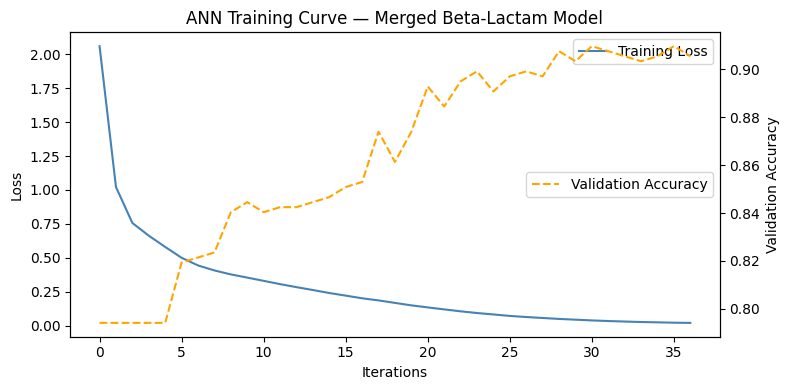

Saved


In [32]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ann2.loss_curve_, label='Training Loss', color='steelblue')

if ann2.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(ann2.validation_scores_, label='Validation Accuracy',
             color='orange', linestyle='--')
    ax2.set_ylabel('Validation Accuracy')
    ax2.legend(loc='center right')

ax.set_xlabel('Iterations')
ax.set_ylabel('Loss')
ax.set_title('ANN Training Curve — Merged Beta-Lactam Model')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("data/training_curve_v2.png", dpi=150)
plt.show()
print("Saved")

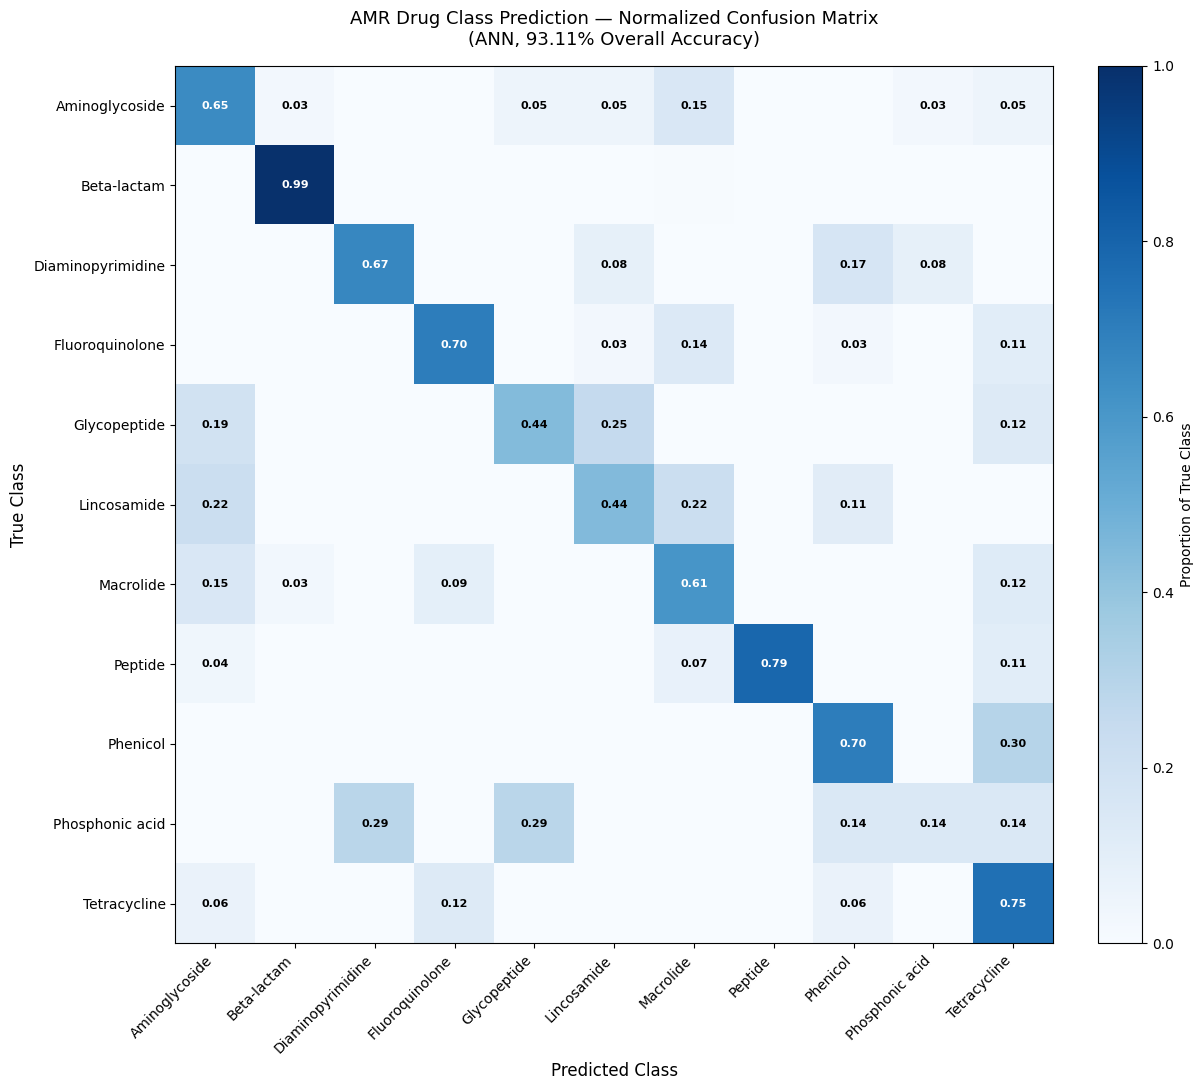

Saved


In [34]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute normalized confusion matrix
cm = confusion_matrix(y_test2, y_pred2)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Shorter class names for display
short_names = [
    'Aminoglycoside',
    'Beta-lactam',
    'Diaminopyrimidine',
    'Fluoroquinolone',
    'Glycopeptide',
    'Lincosamide',
    'Macrolide',
    'Peptide',
    'Phenicol',
    'Phosphonic acid',
    'Tetracycline'
]

fig, ax = plt.subplots(figsize=(13, 11))

im = ax.imshow(cm_normalized, interpolation='nearest', 
               cmap='Blues', vmin=0, vmax=1)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, 
             label='Proportion of True Class')

# Axis labels
ax.set_xticks(range(len(short_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(short_names, fontsize=10)

# Add text annotations
for i in range(len(short_names)):
    for j in range(len(short_names)):
        val = cm_normalized[i, j]
        color = 'white' if val > 0.6 else 'black'
        if val > 0.01:  # only show values above 1%
            ax.text(j, i, f'{val:.2f}',
                   ha='center', va='center',
                   fontsize=8, color=color, fontweight='bold')

ax.set_ylabel('True Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_title('AMR Drug Class Prediction — Normalized Confusion Matrix\n(ANN, 93.11% Overall Accuracy)', 
             fontsize=13, pad=15)

plt.tight_layout()
plt.savefig("data/confusion_matrix_v2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

In [35]:
# Manual mapping based on ResFams profile names to drug classes
# Based on ResFams documentation and known AMR biology

resfams_to_drugclass = {
    # Aminoglycosides
    'AAC3': 'aminoglycoside antibiotic',
    'AAC3-I': 'aminoglycoside antibiotic',
    'AAC6-I': 'aminoglycoside antibiotic',
    'AAC6-Ib': 'aminoglycoside antibiotic',
    'AAC6-II': 'aminoglycoside antibiotic',
    'ANT2': 'aminoglycoside antibiotic',
    'ANT3': 'aminoglycoside antibiotic',
    'ANT4': 'aminoglycoside antibiotic',
    'ANT6': 'aminoglycoside antibiotic',
    'ANT9': 'aminoglycoside antibiotic',
    'APH3': 'aminoglycoside antibiotic',
    'APH6': 'aminoglycoside antibiotic',
    '16S_rRNA_methyltrans': 'aminoglycoside antibiotic',

    # Beta-lactams
    'B1_Metallo': 'beta-lactam antibiotic',
    'B2_Metallo': 'beta-lactam antibiotic',
    'B3_Metallo': 'beta-lactam antibiotic',
    'beta-lactamase_A': 'beta-lactam antibiotic',
    'beta-lactamase_B': 'beta-lactam antibiotic',
    'beta-lactamase_C': 'beta-lactam antibiotic',
    'beta-lactamase_D': 'beta-lactam antibiotic',
    'OXA': 'beta-lactam antibiotic',
    'PBP': 'beta-lactam antibiotic',

    # Tetracyclines
    'Tet_efflux': 'tetracycline antibiotic',
    'Tet_RPP': 'tetracycline antibiotic',
    'Tet_enzyme': 'tetracycline antibiotic',

    # Macrolides
    'Erm': 'macrolide antibiotic',
    'MacA': 'macrolide antibiotic',
    'MacB': 'macrolide antibiotic',
    'mef': 'macrolide antibiotic',

    # Fluoroquinolones
    'Qnr': 'fluoroquinolone antibiotic',
    'AAC6-Ib-cr': 'fluoroquinolone antibiotic',

    # Glycopeptides
    'VanA': 'glycopeptide antibiotic',
    'VanB': 'glycopeptide antibiotic',
    'VanC': 'glycopeptide antibiotic',
    'VanD': 'glycopeptide antibiotic',
    'VanE': 'glycopeptide antibiotic',
    'VanG': 'glycopeptide antibiotic',
    'VanH': 'glycopeptide antibiotic',
    'VanR': 'glycopeptide antibiotic',
    'VanS': 'glycopeptide antibiotic',
    'VanX': 'glycopeptide antibiotic',
    'VanY': 'glycopeptide antibiotic',
    'VanZ': 'glycopeptide antibiotic',

    # Phenicol
    'cat': 'phenicol antibiotic',
    'cml': 'phenicol antibiotic',
    'floR': 'phenicol antibiotic',

    # Trimethoprim (diaminopyrimidine)
    'dfr': 'diaminopyrimidine antibiotic',
    'dfrA': 'diaminopyrimidine antibiotic',

    # Efflux (multi-drug)
    'ABC_efflux': 'multidrug efflux',
    'MFS_efflux': 'multidrug efflux',
    'RND_efflux': 'multidrug efflux',
    'adeA-adeI': 'multidrug efflux',
    'adeB': 'multidrug efflux',
    'adeC-adeK-oprM': 'multidrug efflux',
    'adeR': 'multidrug efflux',
    'adeS': 'multidrug efflux',
    'baeR': 'multidrug efflux',
    'baeS': 'multidrug efflux',
    'emrA': 'multidrug efflux',
    'emrB': 'multidrug efflux',
    'emrR': 'multidrug efflux',
    'evgA': 'multidrug efflux',
    'evgS': 'multidrug efflux',
    'marA': 'multidrug efflux',
    'mdtA': 'multidrug efflux',
    'mdtB': 'multidrug efflux',
    'mdtC': 'multidrug efflux',
    'mexA-mexE': 'multidrug efflux',
    'mexB': 'multidrug efflux',
    'mexC-mexG': 'multidrug efflux',
    'mexD': 'multidrug efflux',
    'mexF': 'multidrug efflux',
    'mexH': 'multidrug efflux',
    'mexT': 'multidrug efflux',
    'mexW-mexV': 'multidrug efflux',
    'mexX': 'multidrug efflux',
    'muxA': 'multidrug efflux',
    'muxB': 'multidrug efflux',
    'muxC': 'multidrug efflux',
    'nalC': 'multidrug efflux',
    'nalD': 'multidrug efflux',
    'nfxB': 'multidrug efflux',
    'OprM': 'multidrug efflux',
    'OprN': 'multidrug efflux',
    'smeA-smeE': 'multidrug efflux',
    'smeB': 'multidrug efflux',
    'smeC-smeF-smeN': 'multidrug efflux',
    'smeD-smeH-smeJ-smeMsmeL': 'multidrug efflux',
    'smeR': 'multidrug efflux',
    'smeS': 'multidrug efflux',
    'triA': 'multidrug efflux',
    'triB': 'multidrug efflux',
    'triC': 'multidrug efflux',
}

print(f"Total ResFams profiles mapped: {len(resfams_to_drugclass)}")

# Save mapping
import json
with open("data/resfams_mapping.json", "w") as f:
    json.dump(resfams_to_drugclass, f, indent=2)

print("Mapping saved to data/resfams_mapping.json")

Total ResFams profiles mapped: 93
Mapping saved to data/resfams_mapping.json


In [36]:
def run_hmmer_and_parse(fasta_file, hmm_db, output_file, evalue=0.01):
    """
    Run hmmscan via WSL and parse results.
    Returns dataframe of hits sorted by evalue.
    """
    import subprocess
    import os

    # Build hmmscan command for WSL
    wsl_fasta = fasta_file.replace("\\", "/").replace("C:", "/mnt/c")
    wsl_hmm = hmm_db.replace("\\", "/").replace("C:", "/mnt/c")
    wsl_output = output_file.replace("\\", "/").replace("C:", "/mnt/c")

    cmd = [
        "wsl", "hmmscan",
        "--tblout", wsl_output,
        "--noali",
        "-E", str(evalue),
        wsl_hmm,
        wsl_fasta
    ]

    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"HMMER error: {result.stderr}")
        return pd.DataFrame()

    # Parse output
    hits = []
    with open(output_file) as f:
        for line in f:
            if line.startswith('#') or line.strip() == '':
                continue
            parts = line.split()
            if len(parts) >= 6:
                hits.append({
                    'hmm_profile': parts[0],
                    'hmm_accession': parts[1],
                    'query_name': parts[2],
                    'evalue': float(parts[4]),
                    'score': float(parts[5]),
                })

    if not hits:
        return pd.DataFrame(columns=[
            'hmm_profile','hmm_accession',
            'query_name','evalue','score'
        ])

    df_hits = pd.DataFrame(hits)
    df_hits = df_hits.sort_values('evalue').reset_index(drop=True)
    return df_hits


print("HMMER parser function defined")

HMMER parser function defined


In [37]:
# Write TEM-1 to a temp fasta file and run full pipeline
tem1_fasta = "data/temp_query.fasta"

with open(tem1_fasta, "w") as f:
    f.write(">TEM-1_test\n")
    f.write(tem1 + "\n")

# Run HMMER
hits = run_hmmer_and_parse(
    fasta_file=tem1_fasta,
    hmm_db="data/resfams/Resfams.hmm",
    output_file="data/temp_hmmer_out.txt",
    evalue=0.01
)

print(f"Total hits: {len(hits)}")
if len(hits) > 0:
    print(f"\nTop 5 hits:")
    print(hits.head())

Total hits: 15

Top 5 hits:
  hmm_profile hmm_accession  query_name         evalue  score
0         TEM        RF0126  TEM-1_test  1.500000e-205  673.6
1     SHV-LEN        RF0119  TEM-1_test  6.800000e-131  428.7
2      ClassA        RF0053  TEM-1_test  4.000000e-130  425.9
3    CARB-PSE        RF0044  TEM-1_test   1.600000e-89  293.1
4        CTXM        RF0059  TEM-1_test   2.600000e-62  203.7


In [38]:
def predict_amr(sequence, hmm_db="data/resfams/Resfams.hmm"):
    """
    Full AMR prediction pipeline:
    1. Run HMMER for profile detection
    2. Run ANN for drug class prediction
    Returns combined result dict
    """
    import tempfile
    import os

    # ── Write sequence to temp file ──────────────────────────
    with tempfile.NamedTemporaryFile(
        mode='w', suffix='.fasta',
        delete=False, dir='data'
    ) as tmp:
        tmp.write(f">query\n{sequence}\n")
        tmp_fasta = tmp.name

    tmp_output = tmp_fasta.replace('.fasta', '_hmmer.txt')

    # ── Run HMMER ────────────────────────────────────────────
    hmmer_hits = run_hmmer_and_parse(
        fasta_file=tmp_fasta,
        hmm_db=hmm_db,
        output_file=tmp_output,
        evalue=0.01
    )

    # ── Run ANN ──────────────────────────────────────────────
    features = get_kmers(sequence, k=3).reshape(1, -1)
    ann_class = le2.inverse_transform(ann2.predict(features))[0]
    ann_probs = ann2.predict_proba(features)[0]
    ann_confidence = ann_probs.max() * 100

    # Top 3 ANN predictions
    top3_idx = ann_probs.argsort()[-3:][::-1]
    top3 = [(le2.classes_[i], round(ann_probs[i]*100, 2)) for i in top3_idx]

    # ── Parse HMMER best hit ─────────────────────────────────
    if len(hmmer_hits) > 0:
        best_hit = hmmer_hits.iloc[0]
        hmm_result = {
            'hit_found': True,
            'profile': best_hit['hmm_profile'],
            'evalue': best_hit['evalue'],
            'score': best_hit['score'],
            'total_hits': len(hmmer_hits),
            'all_hits': hmmer_hits[['hmm_profile','evalue','score']].head(5).to_dict('records')
        }
    else:
        hmm_result = {
            'hit_found': False,
            'profile': None,
            'evalue': None,
            'score': None,
            'total_hits': 0,
            'all_hits': []
        }

    # ── Cleanup temp files ───────────────────────────────────
    os.unlink(tmp_fasta)
    if os.path.exists(tmp_output):
        os.unlink(tmp_output)

    return {
        'hmm': hmm_result,
        'ann': {
            'predicted_class': ann_class,
            'confidence': round(ann_confidence, 2),
            'top3_predictions': top3
        }
    }


print("predict_amr() function defined")

predict_amr() function defined


In [39]:
print("Running full pipeline on TEM-1...\n")
result = predict_amr(tem1)

print("=" * 50)
print("HMM RESULTS")
print("=" * 50)
if result['hmm']['hit_found']:
    print(f"Best profile match : {result['hmm']['profile']}")
    print(f"E-value            : {result['hmm']['evalue']:.2e}")
    print(f"Score              : {result['hmm']['score']}")
    print(f"Total hits         : {result['hmm']['total_hits']}")
    print(f"\nTop hits:")
    for hit in result['hmm']['all_hits']:
        print(f"  {hit['hmm_profile']:20s} E={hit['evalue']:.2e}  score={hit['score']}")
else:
    print("No HMM profile matched")

print("\n" + "=" * 50)
print("ANN RESULTS")
print("=" * 50)
print(f"Predicted class : {result['ann']['predicted_class']}")
print(f"Confidence      : {result['ann']['confidence']}%")
print(f"\nTop 3 predictions:")
for cls, prob in result['ann']['top3_predictions']:
    bar = '█' * int(prob/5)
    print(f"  {cls:30s} {prob:5.1f}% {bar}")

Running full pipeline on TEM-1...

HMM RESULTS
Best profile match : TEM
E-value            : 1.50e-205
Score              : 673.6
Total hits         : 15

Top hits:
  TEM                  E=1.50e-205  score=673.6
  SHV-LEN              E=6.80e-131  score=428.7
  ClassA               E=4.00e-130  score=425.9
  CARB-PSE             E=1.60e-89  score=293.1
  CTXM                 E=2.60e-62  score=203.7

ANN RESULTS
Predicted class : beta-lactam antibiotic
Confidence      : 100.0%

Top 3 predictions:
  beta-lactam antibiotic         100.0% ████████████████████
  macrolide antibiotic             0.0% 
  fluoroquinolone antibiotic       0.0% 
